## Kaggle Setup for DeepGlobe Dataset

This notebook uses the DeepGlobe Land Cover Classification dataset, which is hosted on Kaggle. To use it directly within Kaggle, you need to add the dataset as an input to your notebook.

1. **Add the DeepGlobe Dataset**: In your Kaggle notebook, click on **Add Input** and select the DeepGlobe Land Cover Classification dataset.
2. **Access the Dataset**: Once added, the dataset will be available in the `/kaggle/input/` directory.

All local Windows paths (e.g., `F:\GeoTrack\data\deepglobe`) have been updated to Kaggle-compatible paths (e.g., `/kaggle/input/<dataset-folder-name>`).

In [1]:
!pip install segmentation-models-pytorch albumentations rasterio shapely geopandas fiona pyproj torch torchvision tqdm opencv-python scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.9 MB/s eta 0:00:00


In [2]:
import os

# Define the base directory for data in Kaggle
BASE_KAGGLE_DIR = "/kaggle/working/GeoTrack"
os.makedirs(BASE_KAGGLE_DIR, exist_ok=True)
os.makedirs("/kaggle/working/GeoTrack/data", exist_ok=True)

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

In [4]:
import os

# Dataset is added directly as an input in Kaggle
DATASET_PATH = "/kaggle/input/deepglobe-land-cover-classification-dataset"

print("DeepGlobe dataset path:", DATASET_PATH)
print("\nChecking structure...")

for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        subindent = " " * 2 * (level + 1)
        for f in files[:3]:
            print(f"{subindent}{f}")

DeepGlobe dataset path: /kaggle/input/deepglobe-land-cover-classification-dataset

Checking structure...


Classes:
               name    r    g    b
0        urban_land    0  255  255
1  agriculture_land  255  255    0
2         rangeland  255    0  255
3       forest_land    0  255    0
4             water    0    0  255
5       barren_land  255  255  255
6           unknown    0    0    0

Train images : 803
Train masks  : 803

Image size : (2448, 2448)
Mask size  : (2448, 2448)
Unique mask colors (sample): [[  0   0   0]
 [255   0 255]
 [255 255   0]]


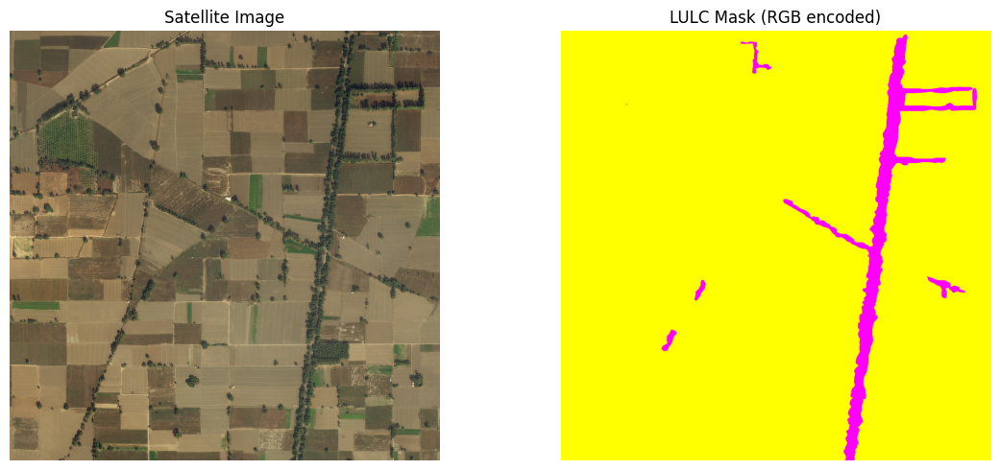

Preview saved.


In [5]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Paths
DATA_DIR  = r"/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset/train"
CLASS_CSV = r"/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset/class_dict.csv"

# Load class definitions
class_df = pd.read_csv(CLASS_CSV)
print("Classes:")
print(class_df)

# Separate images and masks
all_files = sorted(os.listdir(DATA_DIR))
images = [f for f in all_files if f.endswith("_sat.jpg")]
masks  = [f for f in all_files if f.endswith("_mask.png")]

print(f"\nTrain images : {len(images)}")
print(f"Train masks  : {len(masks)}")

# Peek at one pair
img  = Image.open(os.path.join(DATA_DIR, images[0])).convert("RGB")
mask = Image.open(os.path.join(DATA_DIR, masks[0])).convert("RGB")

print(f"\nImage size : {img.size}")
print(f"Mask size  : {mask.size}")
print(f"Unique mask colors (sample): {np.unique(np.array(mask).reshape(-1,3), axis=0)[:8]}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title("Satellite Image")
axes[0].axis("off")
axes[1].imshow(mask)
axes[1].set_title("LULC Mask (RGB encoded)")
axes[1].axis("off")
plt.tight_layout()
plt.savefig(r"/kaggle/working/GeoTrack/data/sample_preview.png", dpi=150)
plt.show()
print("Preview saved.")

### Block 4: Color Mask → Class Index Converter

RGB mask shape   : (2448, 2448, 3)
Class mask shape : (2448, 2448)
Unique classes   : [1 2 6]
Class names present: ['agriculture_land', 'rangeland', 'unknown']


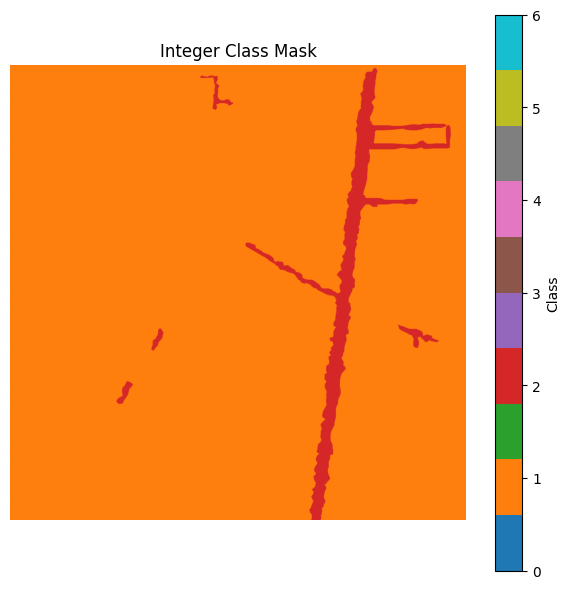

Class mask preview saved.


In [6]:
import numpy as np
from PIL import Image

# Class color map from class_dict.csv
COLOR_TO_CLASS = {
    (0,   255, 255): 0,  # urban_land
    (255, 255,   0): 1,  # agriculture_land
    (255,   0, 255): 2,  # rangeland
    (0,   255,   0): 3,  # forest_land
    (0,     0, 255): 4,  # water
    (255, 255, 255): 5,  # barren_land
    (0,     0,   0): 6,  # unknown
}

CLASS_NAMES = [
    "urban_land",
    "agriculture_land",
    "rangeland",
    "forest_land",
    "water",
    "barren_land",
    "unknown"
]

NUM_CLASSES = 6  # we ignore unknown (class 6) during training

def rgb_mask_to_class(mask_rgb: np.ndarray) -> np.ndarray:
    """
    Convert RGB encoded mask to integer class index mask.
    Input:  HxWx3 numpy array (RGB)
    Output: HxW numpy array (int class index)
    """
    h, w, _ = mask_rgb.shape
    class_mask = np.zeros((h, w), dtype=np.uint8)

    for color, class_idx in COLOR_TO_CLASS.items():
        # Find all pixels matching this color
        match = np.all(mask_rgb == np.array(color), axis=-1)
        class_mask[match] = class_idx

    return class_mask

# Test it on first sample
mask_path = os.path.join(DATA_DIR, masks[0])
mask_rgb   = np.array(Image.open(mask_path).convert("RGB"))
class_mask = rgb_mask_to_class(mask_rgb)

print(f"RGB mask shape   : {mask_rgb.shape}")
print(f"Class mask shape : {class_mask.shape}")
print(f"Unique classes   : {np.unique(class_mask)}")
print(f"Class names present: {[CLASS_NAMES[i] for i in np.unique(class_mask) if i < len(CLASS_NAMES)]}")

# Visualize class mask
plt.figure(figsize=(6,6))
plt.imshow(class_mask, cmap="tab10", vmin=0, vmax=6)
plt.colorbar(ticks=range(7), label="Class")
plt.title("Integer Class Mask")
plt.axis("off")
plt.tight_layout()
plt.savefig(r"/kaggle/working/GeoTrack/data/class_mask_preview.png", dpi=150)
plt.show()
print("Class mask preview saved.")

### Block 5 — Tiling (2448×2448 → 512×512 Patches)
Why We Tile

2448×2448 is too large for CPU training. We cut each image into 512×512 tiles.

Math
Each 2448×2448 image → ~81 tiles
803 images × 81 tiles = ~65,000 patches → too many for CPU
We use 200 images → ~16,000 tiles → manageable

In [ ]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

# Config
TILE_SIZE   = 512
NUM_IMAGES  = 803  # prototype subset
TILES_DIR = "/kaggle/working/GeoTrack/data/tiles"

os.makedirs(os.path.join(TILES_DIR, "images"), exist_ok=True)
os.makedirs(os.path.join(TILES_DIR, "masks"),  exist_ok=True)

def tile_image_and_mask(img_path, mask_path, tile_size=512):
    """
    Cut image and mask into non-overlapping tiles.
    Skips tiles where >50% pixels are unknown class (6).
    Returns list of (image_tile, mask_tile) numpy arrays.
    """
    img  = np.array(Image.open(img_path).convert("RGB"))
    mask = np.array(Image.open(mask_path).convert("RGB"))
    mask = rgb_mask_to_class(mask)

    h, w = img.shape[:2]
    tiles = []

    for y in range(0, h - tile_size + 1, tile_size):
        for x in range(0, w - tile_size + 1, tile_size):
            img_tile  = img[y:y+tile_size,  x:x+tile_size]
            mask_tile = mask[y:y+tile_size, x:x+tile_size]

            # Skip tiles dominated by unknown class
            unknown_ratio = np.sum(mask_tile == 6) / (tile_size * tile_size)
            if unknown_ratio > 0.5:
                continue

            tiles.append((img_tile, mask_tile))

    return tiles

# Process subset
tile_count = 0
subset = images[:NUM_IMAGES]

print(f"Tiling {NUM_IMAGES} images into {TILE_SIZE}x{TILE_SIZE} patches...")

for fname in tqdm(subset):
    img_path  = os.path.join(DATA_DIR, fname)
    mask_fname = fname.replace("_sat.jpg", "_mask.png")
    mask_path  = os.path.join(DATA_DIR, mask_fname)

    if not os.path.exists(mask_path):
        continue

    tiles = tile_image_and_mask(img_path, mask_path, TILE_SIZE)

    for img_tile, mask_tile in tiles:
        Image.fromarray(img_tile).save(
            os.path.join(TILES_DIR, "images", f"tile_{tile_count:05d}.png"))
        Image.fromarray(mask_tile).save(
            os.path.join(TILES_DIR, "masks",  f"tile_{tile_count:05d}.png"))
        tile_count += 1
  
print(f"\nDone. Total tiles generated : {tile_count}")
print(f"Saved to : {TILES_DIR}")

Tiling 803 images into 512x512 patches...


100%|██████████| 803/803 [40:48<00:00,  3.05s/it]


Done. Total tiles generated : 12844
Saved to : /kaggle/working/GeoTrack/data/tiles


Mask unique values : [1 2]
Mask min/max       : 1 / 2
Image min/max      : 0 / 255


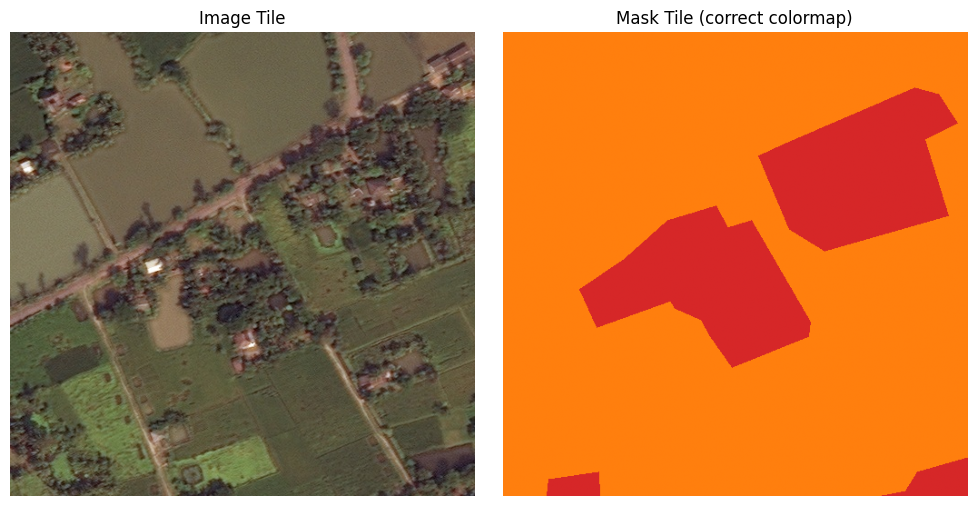

In [8]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

TILES_DIR = "/kaggle/working/GeoTrack/data/tiles"

# Check one mask tile
mask_tile = np.array(Image.open(f"{TILES_DIR}/masks/tile_00590.png"))
img_tile  = np.array(Image.open(f"{TILES_DIR}/images/tile_00590.png"))

print(f"Mask unique values : {np.unique(mask_tile)}")
print(f"Mask min/max       : {mask_tile.min()} / {mask_tile.max()}")
print(f"Image min/max      : {img_tile.min()} / {img_tile.max()}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_tile)
axes[0].set_title("Image Tile")
axes[0].axis("off")
axes[1].imshow(mask_tile, cmap="tab10", vmin=0, vmax=6)
axes[1].set_title("Mask Tile (correct colormap)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

### Block 6 — Dataset Class & DataLoader
What This Does
Loads image and mask tiles from disk
Applies augmentations during training (flips, rotations)
Wraps everything in PyTorch Dataset and DataLoader — this is how PyTorch feeds data to the model batch by batch

In [9]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Paths
TILES_IMG_DIR  = "/kaggle/working/GeoTrack/data/tiles/images"
TILES_MASK_DIR = "/kaggle/working/GeoTrack/data/tiles/masks"

# Get all tile filenames
all_tiles = sorted(os.listdir(TILES_IMG_DIR))
print(f"Total tiles: {len(all_tiles)}")

# Train / Val split
train_tiles, val_tiles = train_test_split(
    all_tiles,
    test_size=0.2,
    random_state=42
)
print(f"Train tiles : {len(train_tiles)}")
print(f"Val tiles   : {len(val_tiles)}")

# Augmentations for training
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# No augmentation for validation — just normalize
val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Dataset class
class DeepGlobeDataset(Dataset):
    """
    PyTorch Dataset for DeepGlobe tiles.
    __len__  → tells PyTorch how many samples exist
    __getitem__ → loads one image+mask pair by index
    """
    def __init__(self, tile_names, img_dir, mask_dir, transform=None):
        self.tile_names = tile_names
        self.img_dir    = img_dir
        self.mask_dir   = mask_dir
        self.transform  = transform

    def __len__(self):
        return len(self.tile_names)

    def __getitem__(self, idx):
        fname = self.tile_names[idx]

        # Load image as RGB numpy array
        img  = np.array(Image.open(os.path.join(self.img_dir,  fname)).convert("RGB"))

        # Load mask as single channel
        mask = np.array(Image.open(os.path.join(self.mask_dir, fname)))

        # Cap unknown class (6) to 5 — treat as barren_land
        mask = np.clip(mask, 0, 5)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img  = augmented["image"]
            mask = augmented["mask"].long()

        return img, mask

# Create datasets
train_dataset = DeepGlobeDataset(train_tiles, TILES_IMG_DIR, TILES_MASK_DIR, train_transform)
val_dataset   = DeepGlobeDataset(val_tiles,   TILES_IMG_DIR, TILES_MASK_DIR, val_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=0)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

# Sanity check — load one batch
imgs, masks = next(iter(train_loader))
print(f"\nBatch image shape : {imgs.shape}")
print(f"Batch mask shape  : {masks.shape}")
print(f"Image dtype       : {imgs.dtype}")
print(f"Mask dtype        : {masks.dtype}")
print(f"Mask unique vals  : {masks.unique()}")

Total tiles: 12844
Train tiles : 10275
Val tiles   : 2569

Train batches : 643
Val batches   : 161

Batch image shape : torch.Size([16, 3, 512, 512])
Batch mask shape  : torch.Size([16, 512, 512])
Image dtype       : torch.float32
Mask dtype        : torch.int64
Mask unique vals  : tensor([0, 1, 2, 3, 4, 5])


### Block 7 — Model Definition
What This Does
Loads U-Net with a pretrained ResNet34 encoder in literally 3 lines. This is why we installed segmentation-models-pytorch.

Why ResNet34
Pretrained on ImageNet — already knows edges, textures, shapes
We only need to teach it LULC-specific patterns
Lightweight enough for CPU training
Why U-Net
Encoder compresses image → extracts features
Decoder expands back → produces pixel-wise predictions
Skip connections preserve spatial detail lost during compression

In [10]:
import segmentation_models_pytorch as smp
import torch

# Define model
model = smp.Unet(
    encoder_name    = "resnet34",      # pretrained feature extractor
    encoder_weights = "imagenet",      # pretrained on ImageNet
    in_channels     = 3,               # RGB input
    classes         = 6,               # 6 LULC classes
    activation      = None             # raw logits — loss function handles activation
)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

# Verify with one forward pass
model.eval()
with torch.no_grad():
    dummy_input = torch.randn(1, 3, 256, 256)
    dummy_output = model(dummy_input)
    print(f"\nInput shape  : {dummy_input.shape}")
    print(f"Output shape : {dummy_output.shape}")
    print(f"\nOutput shape means: [1 image, 6 class scores, 256x256 pixels]")
    print("Model is working correctly.")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Total parameters     : 24,437,094
Trainable parameters : 24,437,094

Input shape  : torch.Size([1, 3, 256, 256])
Output shape : torch.Size([1, 6, 256, 256])

Output shape means: [1 image, 6 class scores, 256x256 pixels]
Model is working correctly.


### Block 8 — Loss Function & Optimizer
What This Does

Defines how the model measures its own mistakes and how it corrects them.

Two Loss Functions Combined

CrossEntropyLoss — penalizes wrong class predictions per pixel

DiceLoss — penalizes poor overlap between predicted and actual segmentation regions. Critical for imbalanced classes like water or barren land which appear rarely.

We combine both because CrossEntropy alone struggles with class imbalance in LULC data.

Optimizer

Adam — standard, works well, no tuning needed for prototype.

In [11]:
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = torch.nn.DataParallel(model)

model = model.to(DEVICE)

# Move model to GPU
model = model.to(DEVICE)

# Loss functions
ce_loss   = nn.CrossEntropyLoss().to(DEVICE)
dice_loss = smp.losses.DiceLoss(mode="multiclass", classes=6)

def combined_loss(pred, target):
    pred   = pred.to(DEVICE)
    target = target.to(DEVICE)
    return ce_loss(pred, target) + dice_loss(pred, target)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode    = "min",
    patience= 2,
    factor  = 0.5
)

# Sanity check
print(f"GPU count: {torch.cuda.device_count()}")

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")


model.eval()
with torch.no_grad():
    dummy_imgs  = torch.randn(2, 3, 256, 256).to(DEVICE)
    dummy_masks = torch.zeros(2, 256, 256, dtype=torch.long).to(DEVICE)
    dummy_preds = model(dummy_imgs)
    loss_val    = combined_loss(dummy_preds, dummy_masks)
    print(f"Device            : {DEVICE}")
    print(f"Sanity check loss : {loss_val.item():.4f}")
    print("All on GPU. Ready to train.")

Using 2 GPUs
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
Device            : cuda
Sanity check loss : 1.5484
All on GPU. Ready to train.


### Block 9 — Training Loop

#### What This Does

Trains the model for multiple epochs. Each epoch consists of:

- **Train phase** — The model sees training tiles, makes predictions, calculates the combined Cross-Entropy and Dice loss, and updates its weights.
- **Validation phase** — The model sees validation tiles without updating its weights. It evaluates the model using **Validation Loss, Mean IoU, Pixel Accuracy, and Mean Dice Score**.

#### Metrics Monitored

- **Train Loss** — Measures how well the model fits the training data.
- **Validation Loss** — Measures how well the model performs on unseen validation data.
- **Mean IoU (mIoU)** — The primary segmentation metric, calculated as the average IoU across all land-cover classes.
- **Pixel Accuracy** — The proportion of all pixels that are classified correctly.
- **Mean Dice Score** — Measures the overlap between predicted and ground-truth regions and is especially useful alongside IoU for evaluating segmentation performance.

#### What is IoU?

**Intersection over Union (IoU)** is the primary metric used to evaluate semantic segmentation.

```text
IoU = (pixels correctly predicted as class X) /
      (all pixels predicted OR actually belonging to class X)

In [12]:
import torch
import numpy as np
from tqdm import tqdm
import os

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS      = 20
NUM_CLASSES = 6

CLASS_NAMES = ["urban", "agriculture", "rangeland",
               "forest", "water", "barren"]

model = model.to(DEVICE)

# -- Save Path
MODEL_SAVE_DIR = os.path.join(BASE_KAGGLE_DIR, "model")
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
MODEL_PATH = os.path.join(MODEL_SAVE_DIR, "unet_resnet34_best.pth")

# -- Metrics
def compute_iou(preds, masks, num_classes=6):
    pred_classes = torch.argmax(preds, dim=1)
    iou_list = []
    for cls in range(num_classes):
        pred_cls   = (pred_classes == cls)
        target_cls = (masks == cls)
        intersection = (pred_cls & target_cls).sum().float()
        union        = (pred_cls | target_cls).sum().float()
        if union == 0:
            continue
        iou_list.append((intersection / union).item())
    return np.mean(iou_list) if iou_list else 0.0

def compute_pixel_accuracy(preds, masks):
    pred_classes = torch.argmax(preds, dim=1)
    correct = (pred_classes == masks).sum().float()
    total   = masks.numel()
    return (correct / total).item()

def compute_dice(preds, masks, num_classes=6):
    pred_classes = torch.argmax(preds, dim=1)
    dice_scores  = []
    for cls in range(num_classes):
        pred_cls   = (pred_classes == cls)
        target_cls = (masks == cls)
        intersection = (pred_cls & target_cls).sum().float()
        denominator  = pred_cls.sum().float() + target_cls.sum().float()
        if denominator == 0:
            continue
        dice_scores.append((2.0 * intersection / denominator).item())
    return np.mean(dice_scores) if dice_scores else 0.0

def compute_per_class_iou(preds, masks, num_classes=6):
    pred_classes = torch.argmax(preds, dim=1)
    class_iou = {}
    for cls in range(num_classes):
        pred_cls   = (pred_classes == cls)
        target_cls = (masks == cls)
        intersection = (pred_cls & target_cls).sum().float()
        union        = (pred_cls | target_cls).sum().float()
        if union == 0:
            continue
        class_iou[CLASS_NAMES[cls]] = round((intersection / union).item(), 4)
    return class_iou

# -- History
history = {
    "train_loss"        : [],
    "val_loss"          : [],
    "val_iou"           : [],
    "val_pixel_accuracy": [],
    "val_dice"          : [],
    "per_class_iou"     : {}
}

best_miou = 0.0

print(f"Training on : {DEVICE}")
print(f"Epochs      : {EPOCHS}")
print(f"Train batches per epoch : {len(train_loader)}")
print("-" * 50)

for epoch in range(EPOCHS):

    # -- Train
    model.train()
    train_loss = 0.0
    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        imgs  = imgs.to(DEVICE)
        masks = masks.to(DEVICE)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = combined_loss(preds, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # -- Val
    model.eval()
    val_loss = val_iou = val_pixel_accuracy = val_dice = 0.0
    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]  "):
            imgs  = imgs.to(DEVICE)
            masks = masks.to(DEVICE)
            preds = model(imgs)
            val_loss           += combined_loss(preds, masks).item()
            val_iou            += compute_iou(preds, masks)
            val_pixel_accuracy += compute_pixel_accuracy(preds, masks)
            val_dice           += compute_dice(preds, masks)

    val_loss           /= len(val_loader)
    val_iou            /= len(val_loader)
    val_pixel_accuracy /= len(val_loader)
    val_dice           /= len(val_loader)

    scheduler.step(val_loss)

    # -- History
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_iou"].append(val_iou)
    history["val_pixel_accuracy"].append(val_pixel_accuracy)
    history["val_dice"].append(val_dice)

    # -- Save Best
    if val_iou > best_miou:
        best_miou = val_iou
        torch.save(model.state_dict(), MODEL_PATH)
        print(f"  Best model saved — mIoU: {val_iou:.4f}")

    # -- Per-class IoU every 5 epochs
    if (epoch + 1) % 5 == 0:
        imgs, masks = next(iter(val_loader))
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        with torch.no_grad():
            preds = model(imgs)
        per_class = compute_per_class_iou(preds, masks)
        history["per_class_iou"][f"epoch_{epoch+1}"] = per_class
        print(f"  Per-class IoU:")
        for cls, iou in per_class.items():
            print(f"    {cls:<15}: {iou:.4f}")

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss         : {train_loss:.4f}")
    print(f"  Val Loss           : {val_loss:.4f}")
    print(f"  Val mIoU           : {val_iou:.4f}")
    print(f"  Val Pixel Accuracy : {val_pixel_accuracy:.4f}")
    print(f"  Val Mean Dice      : {val_dice:.4f}")
    print(f"  Best mIoU so far   : {best_miou:.4f}")
    print("-" * 50)

print(f"\nTraining complete.")
print(f"Best mIoU  : {best_miou:.4f}")
print(f"Model saved: {MODEL_PATH}")

Training on : cuda
Epochs      : 20
Train batches per epoch : 643
--------------------------------------------------


Epoch 1/20 [Val]  : 100%|██████████| 161/161 [01:12<00:00,  2.22it/s]


  Best model saved — mIoU: 0.5316

Epoch 1/20
  Train Loss         : 1.5501
  Val Loss           : 0.9982
  Val mIoU           : 0.5316
  Val Pixel Accuracy : 0.8274
  Val Mean Dice      : 0.6326
  Best mIoU so far   : 0.5316
--------------------------------------------------


Epoch 2/20 [Val]  : 100%|██████████| 161/161 [01:13<00:00,  2.19it/s]


  Best model saved — mIoU: 0.5578

Epoch 2/20
  Train Loss         : 1.0975
  Val Loss           : 0.8577
  Val mIoU           : 0.5578
  Val Pixel Accuracy : 0.8411
  Val Mean Dice      : 0.6579
  Best mIoU so far   : 0.5578
--------------------------------------------------


...


Epoch 18/20
  Train Loss         : 0.5817
  Val Loss           : 0.6141
  Val mIoU           : 0.6570
  Val Pixel Accuracy : 0.8833
  Val Mean Dice      : 0.7537
  Best mIoU so far   : 0.6721
--------------------------------------------------


Epoch 19/20 [Val]  : 100%|██████████| 161/161 [01:12<00:00,  2.21it/s]



Epoch 19/20
  Train Loss         : 0.5819
  Val Loss           : 0.5985
  Val mIoU           : 0.6636
  Val Pixel Accuracy : 0.8860
  Val Mean Dice      : 0.7582
  Best mIoU so far   : 0.6721
--------------------------------------------------


Epoch 20/20 [Val]  : 100%|██████████| 161/161 [01:13<00:00,  2.19it/s]


  Per-class IoU:
    urban          : 0.8034
    agriculture    : 0.9019
    rangeland      : 0.4940
    forest         : 0.7198
    water          : 0.7251
    barren         : 0.8317

Epoch 20/20
  Train Loss         : 0.5686
  Val Loss           : 0.5987
  Val mIoU           : 0.6699
  Val Pixel Accuracy : 0.8847
  Val Mean Dice      : 0.7659
  Best mIoU so far   : 0.6721
--------------------------------------------------

Training complete.
Best mIoU  : 0.6721
Model saved: /kaggle/working/GeoTrack/model/unet_resnet34_best.pth


In [13]:
import os

MODEL_SAVE_PATH = "/kaggle/working/GeoTrack/model/unet_resnet34_e2.pth"
os.makedirs("/kaggle/working/GeoTrack/model", exist_ok=True)
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Checkpoint saved: {MODEL_SAVE_PATH}")

Checkpoint saved: /kaggle/working/GeoTrack/model/unet_resnet34_e2.pth


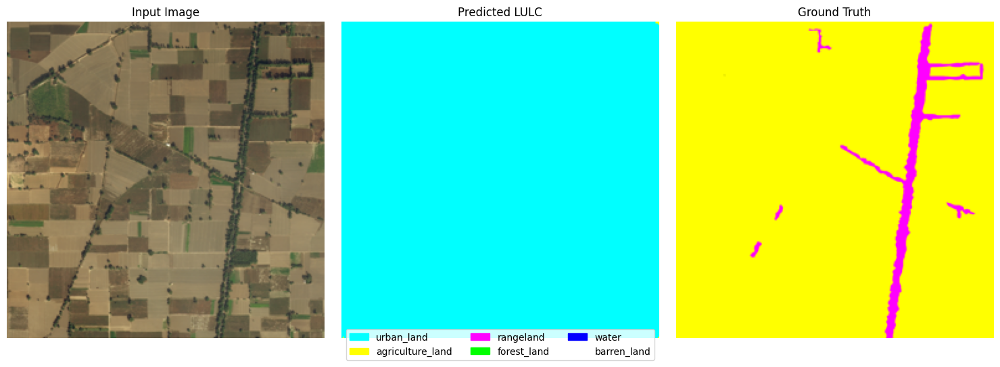

Saved to /kaggle/working/GeoTrack/outputs/prediction_1.png


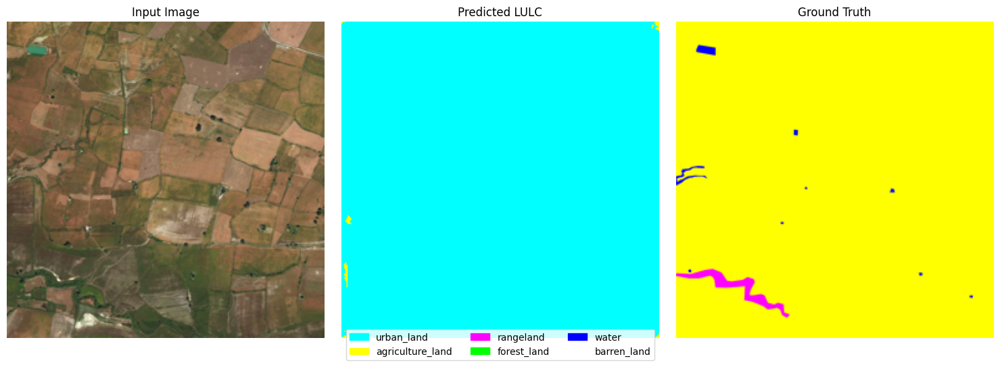

Saved to /kaggle/working/GeoTrack/outputs/prediction_2.png


In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os

OUTPUT_DIR = "/kaggle/working/GeoTrack/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASS_COLORS = {
    0: (0,   255, 255),  # urban_land
    1: (255, 255,   0),  # agriculture_land
    2: (255,   0, 255),  # rangeland
    3: (0,   255,   0),  # forest_land
    4: (0,     0, 255),  # water
    5: (255, 255, 255),  # barren_land
}

CLASS_NAMES = [
    "urban_land", "agriculture_land", "rangeland",
    "forest_land", "water", "barren_land"
]

def predict_single(img_path, mask_path=None, save_name="prediction_preview.png"):
    img = np.array(Image.open(img_path).convert("RGB"))
    img_resized = np.array(Image.fromarray(img).resize((256, 256)))

    transform = A.Compose([
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])

    tensor = transform(image=img_resized)["image"].unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        output = model(tensor)
        pred   = torch.argmax(output, dim=1).squeeze().cpu().numpy()

    pred_rgb = np.zeros((256, 256, 3), dtype=np.uint8)
    for cls, color in CLASS_COLORS.items():
        pred_rgb[pred == cls] = color

    ncols = 3 if mask_path else 2
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5))

    axes[0].imshow(img_resized)
    axes[0].set_title("Input Image")
    axes[0].axis("off")

    axes[1].imshow(pred_rgb)
    axes[1].set_title("Predicted LULC")
    axes[1].axis("off")

    if mask_path:
        mask = np.array(Image.open(mask_path).convert("RGB"))
        mask = np.array(Image.fromarray(mask).resize((256, 256)))
        axes[2].imshow(mask)
        axes[2].set_title("Ground Truth")
        axes[2].axis("off")

    patches = [plt.Rectangle((0,0),1,1, color=[c/255 for c in col])
               for col in CLASS_COLORS.values()]
    fig.legend(patches, CLASS_NAMES, loc="lower center",
               ncol=3, bbox_to_anchor=(0.5, -0.05))

    plt.tight_layout()
    save_path = f"{OUTPUT_DIR}/{save_name}"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {save_path}")

# Reload file lists
all_files   = sorted(os.listdir(DATA_DIR))
images_list = [f for f in all_files if f.endswith("_sat.jpg")]
masks_list  = [f for f in all_files if f.endswith("_mask.png")]

# Run on first sample
sample_img  = os.path.join(DATA_DIR, images_list[0])
sample_mask = os.path.join(DATA_DIR, masks_list[0])
predict_single(sample_img, sample_mask, save_name="prediction_1.png")

# Run on second sample
sample_img2  = os.path.join(DATA_DIR, images_list[1])
sample_mask2 = os.path.join(DATA_DIR, masks_list[1])
predict_single(sample_img2, sample_mask2, save_name="prediction_2.png")

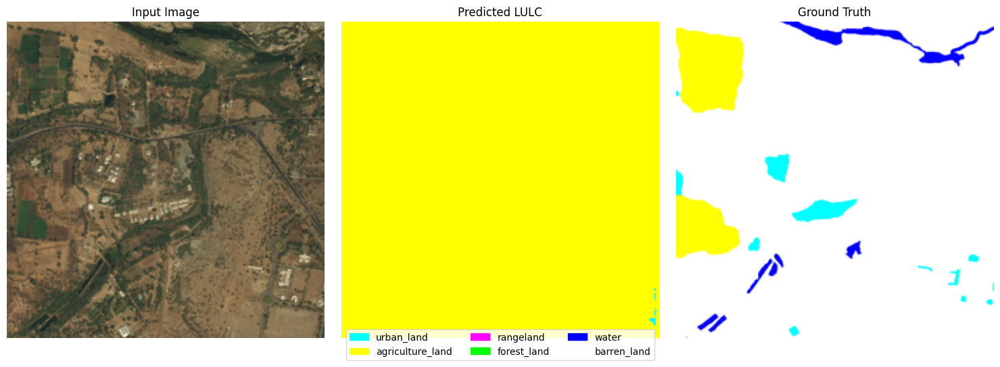

Saved to /kaggle/working/GeoTrack/outputs/prediction_654.png


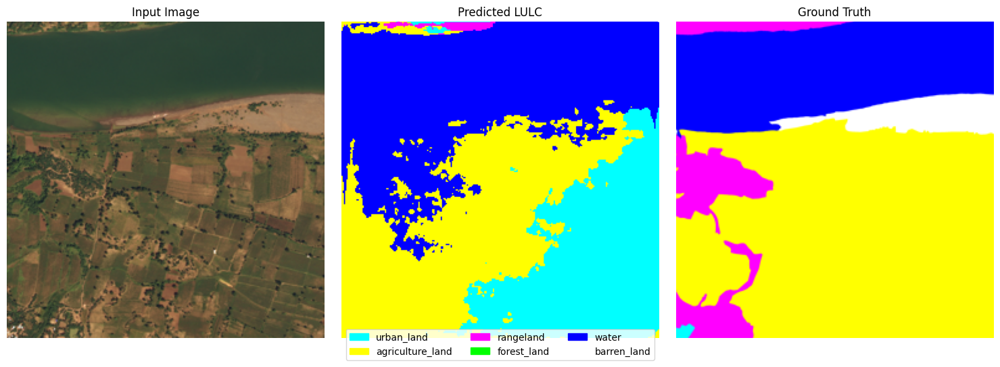

Saved to /kaggle/working/GeoTrack/outputs/prediction_114.png


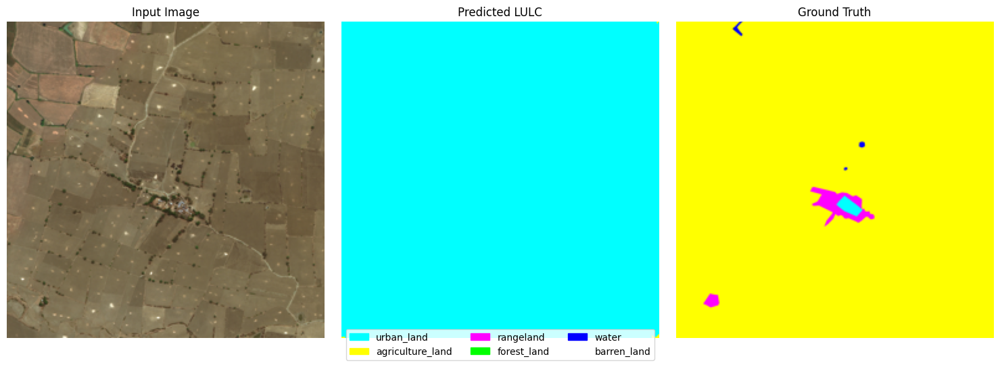

Saved to /kaggle/working/GeoTrack/outputs/prediction_25.png


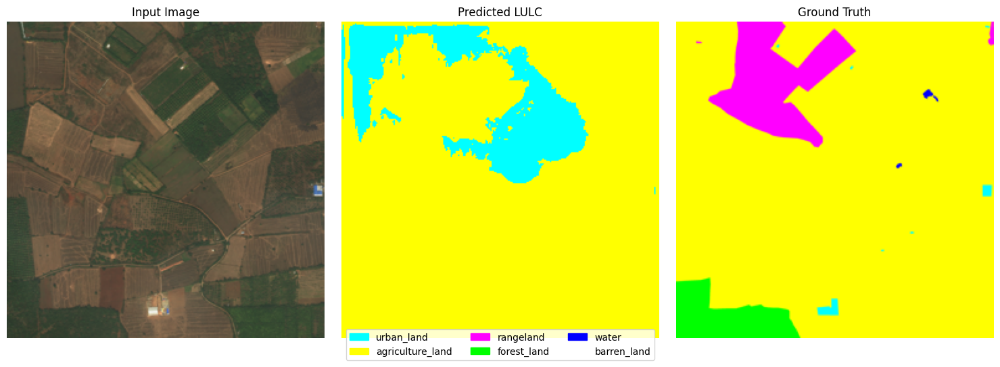

Saved to /kaggle/working/GeoTrack/outputs/prediction_759.png


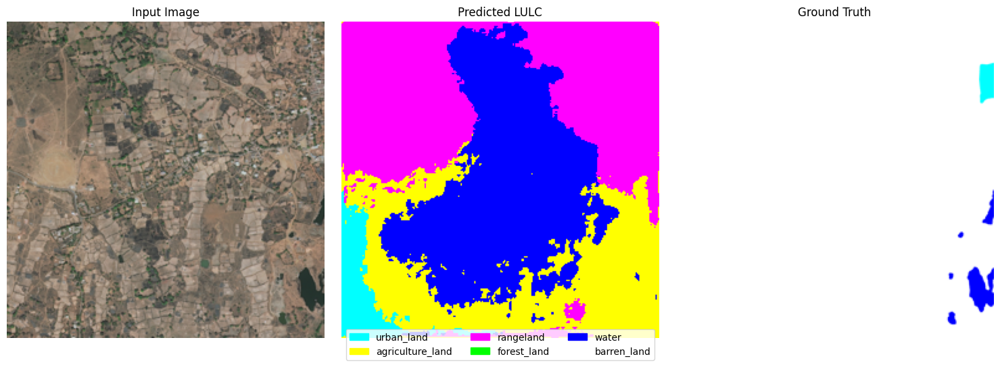

Saved to /kaggle/working/GeoTrack/outputs/prediction_281.png


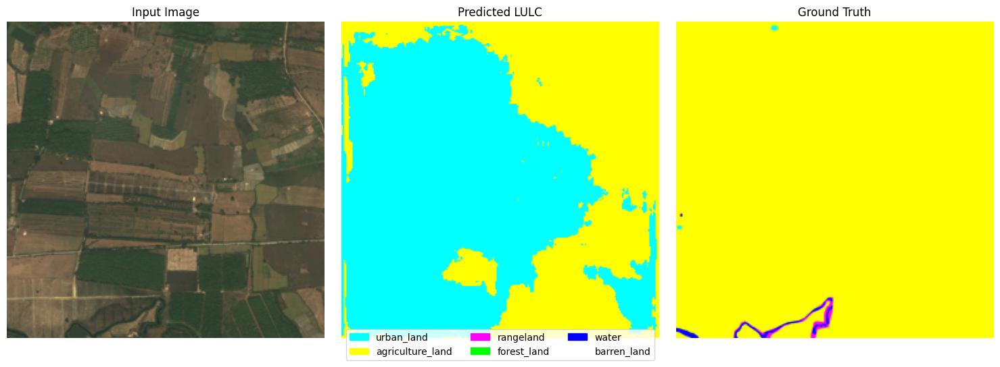

Saved to /kaggle/working/GeoTrack/outputs/prediction_250.png


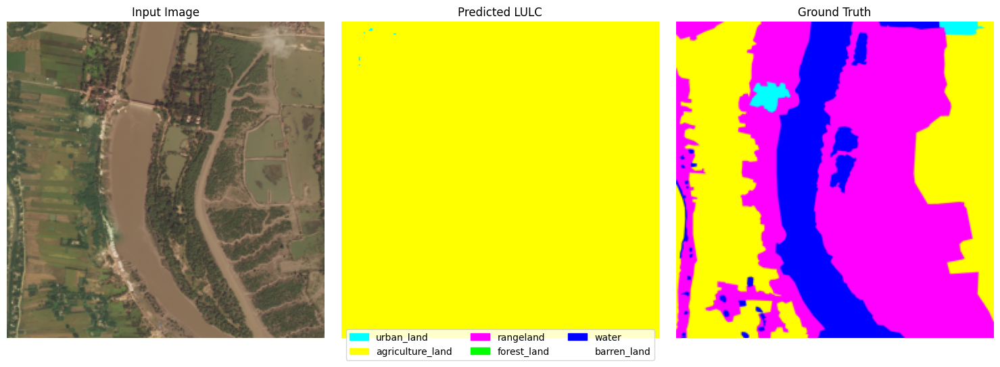

Saved to /kaggle/working/GeoTrack/outputs/prediction_228.png


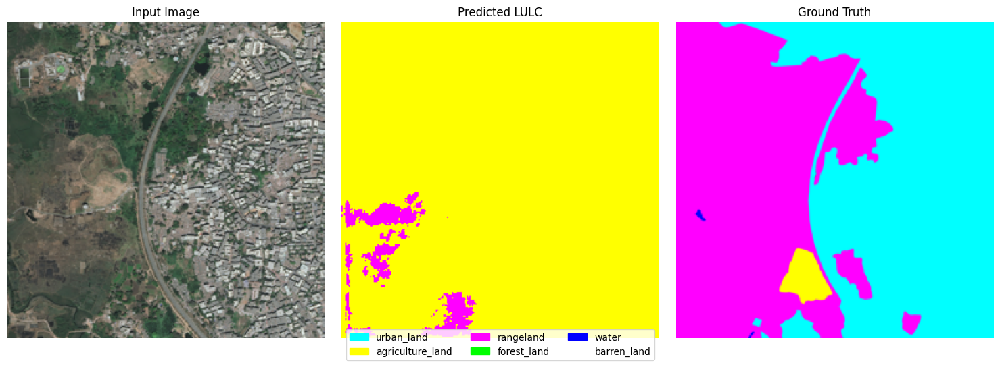

Saved to /kaggle/working/GeoTrack/outputs/prediction_142.png


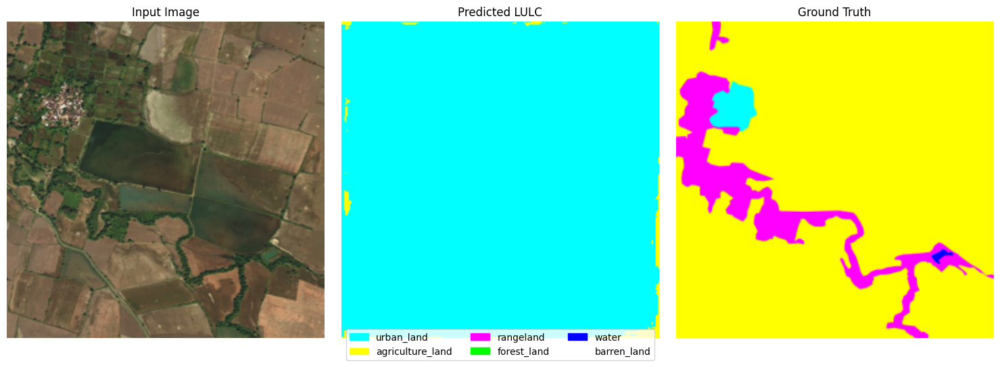

Saved to /kaggle/working/GeoTrack/outputs/prediction_754.png


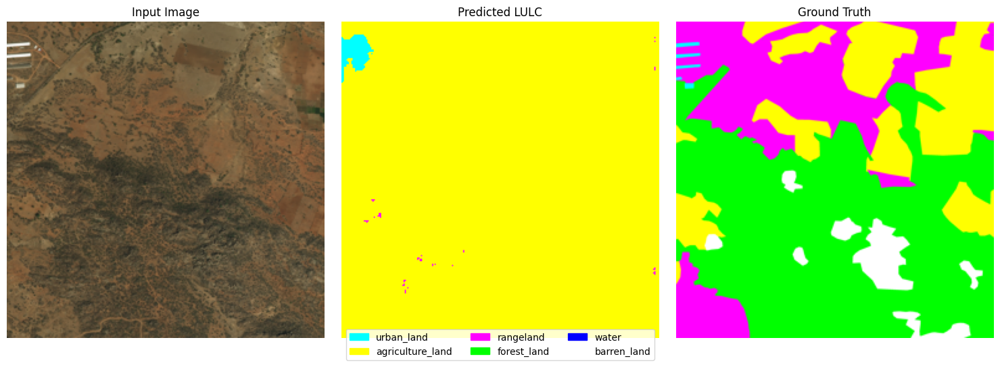

Saved to /kaggle/working/GeoTrack/outputs/prediction_104.png


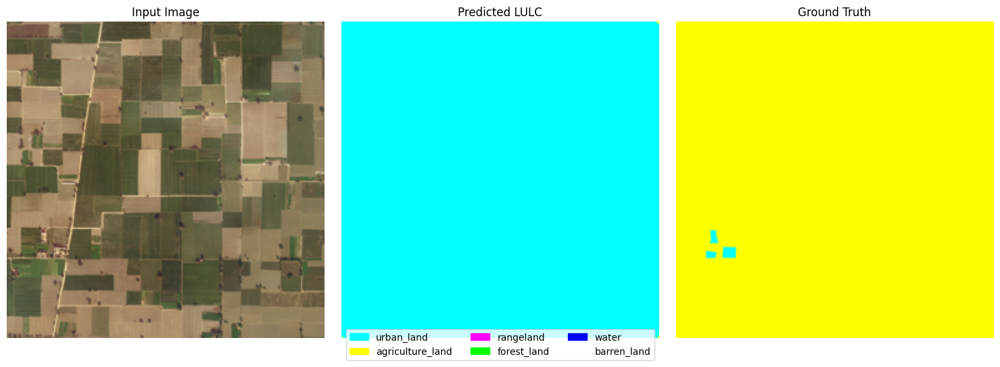

Saved to /kaggle/working/GeoTrack/outputs/prediction_692.png


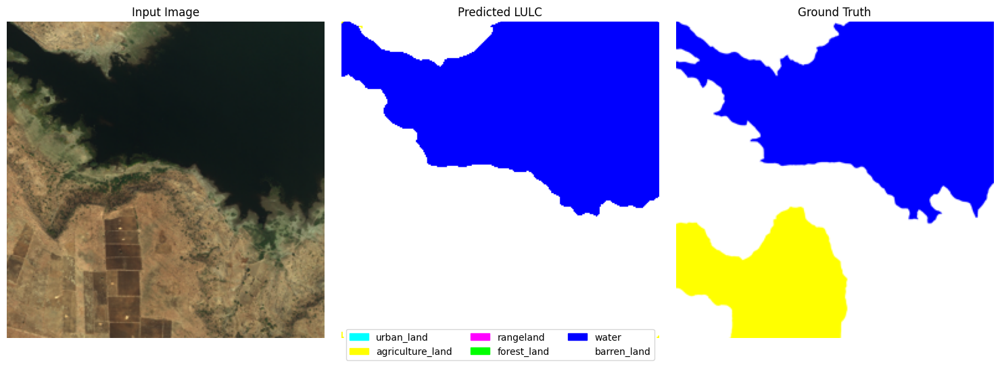

Saved to /kaggle/working/GeoTrack/outputs/prediction_758.png


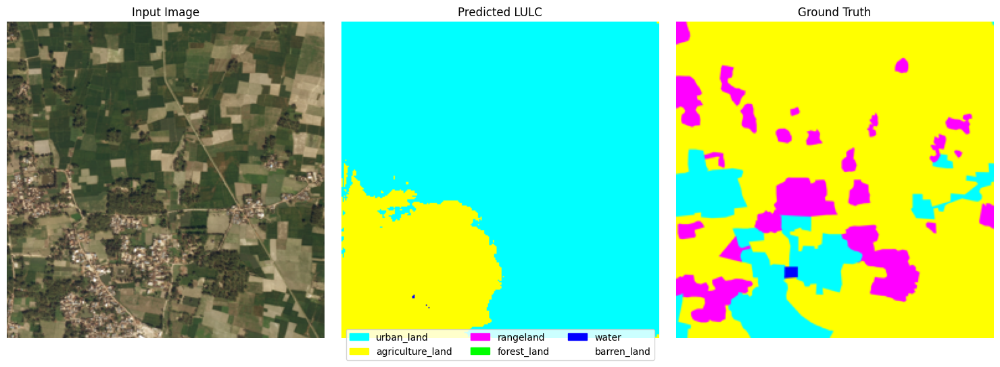

Saved to /kaggle/working/GeoTrack/outputs/prediction_558.png


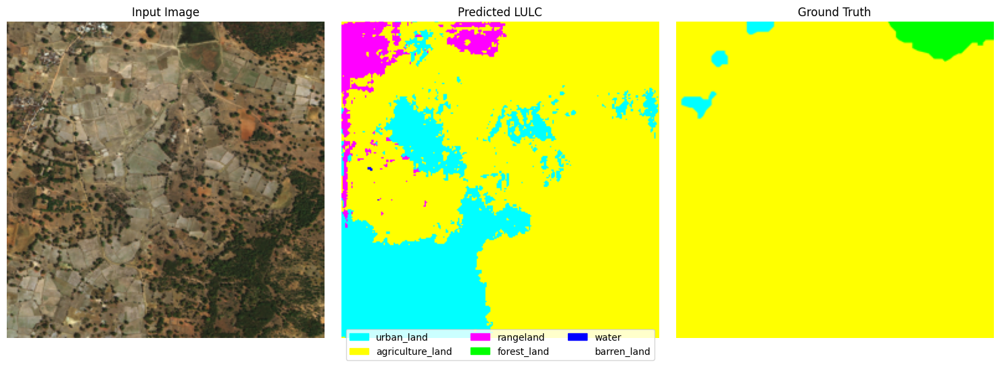

Saved to /kaggle/working/GeoTrack/outputs/prediction_89.png


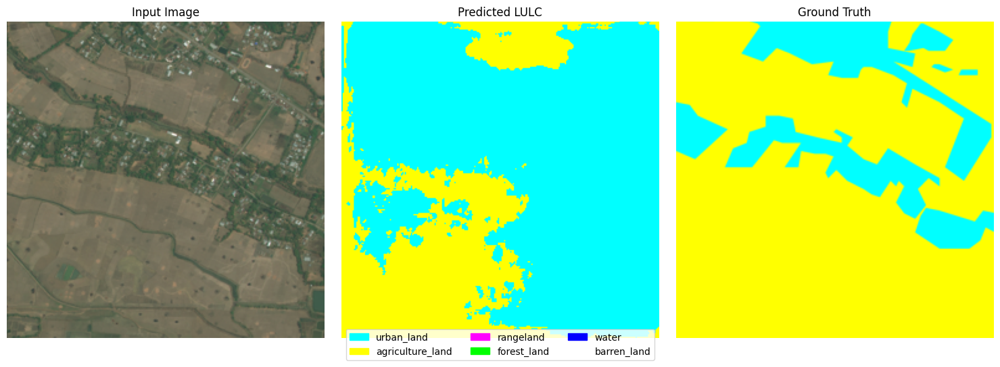

Saved to /kaggle/working/GeoTrack/outputs/prediction_604.png


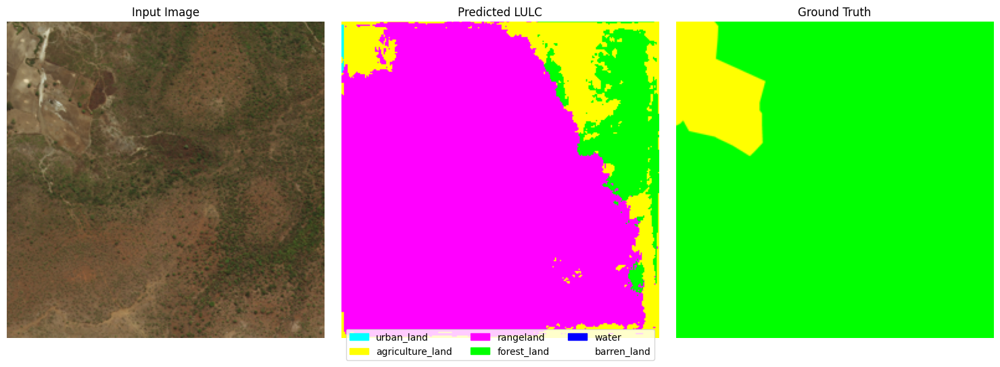

Saved to /kaggle/working/GeoTrack/outputs/prediction_432.png


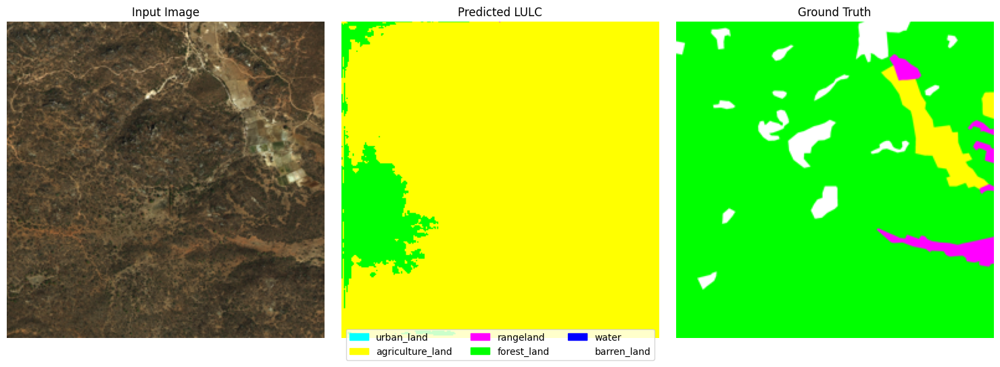

Saved to /kaggle/working/GeoTrack/outputs/prediction_32.png


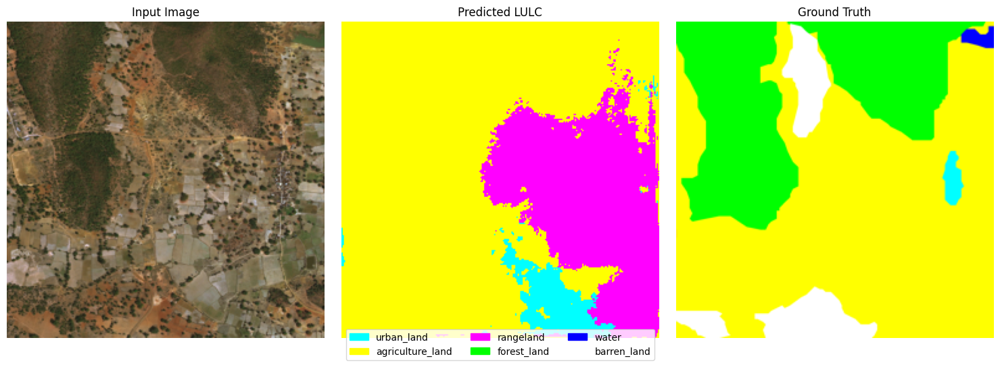

Saved to /kaggle/working/GeoTrack/outputs/prediction_30.png


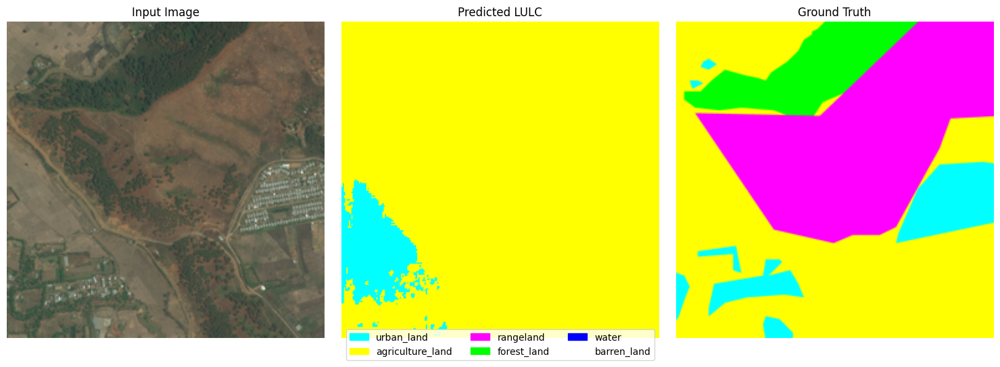

Saved to /kaggle/working/GeoTrack/outputs/prediction_95.png


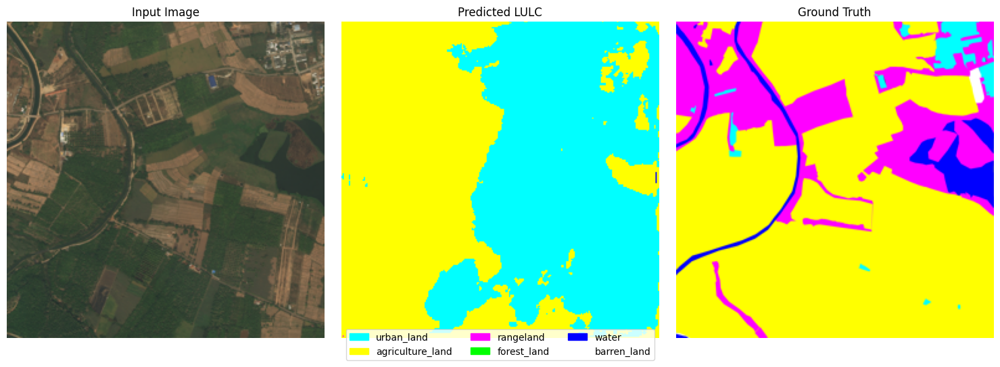

Saved to /kaggle/working/GeoTrack/outputs/prediction_223.png


In [15]:
import random

random.seed(42)
sample_indices = random.sample(range(len(images_list)), 20)

for i in sample_indices:
    sample_img  = os.path.join(DATA_DIR, images_list[i])
    sample_mask = os.path.join(DATA_DIR, masks_list[i])
    predict_single(sample_img, sample_mask, save_name=f"prediction_{i}.png")

In [ ]:
import os
import matplotlib.pyplot as plt
from datetime import datetime

OUTPUT_DIR = "/kaggle/working/GeoTrack/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Metrics ───────────────────────────────────────────
epochs = list(range(1, len(history["train_loss"]) + 1))

best_miou              = max(history["val_iou"])
best_miou_epoch        = history["val_iou"].index(best_miou) + 1
best_pixel_accuracy    = max(history["val_pixel_accuracy"])
best_pixel_accuracy_epoch = history["val_pixel_accuracy"].index(best_pixel_accuracy) + 1
best_dice              = max(history["val_dice"])
best_dice_epoch        = history["val_dice"].index(best_dice) + 1

gap     = 0.67 - best_miou
gap_str = f"+{abs(gap):.4f} above baseline" if gap < 0 else f"{gap:.4f} below baseline"

# ── Figure ────────────────────────────────────────────
fig = plt.figure(figsize=(24, 16))
fig.patch.set_facecolor("#f9f9f9")

fig.text(0.5, 0.975, "GeoTrack — Training Report",
         ha="center", fontsize=26, fontweight="bold")

fig.text(0.5, 0.945,
         f"Model: U-Net + ResNet34  |  Dataset: DeepGlobe Land Cover  |  "
         f"Epochs: {len(epochs)}  |  Images: 803  |  Tiles: 16,191  |  "
         f"Batch: 16  |  LR: 1e-4  |  Loss: CrossEntropy + Dice  |  "
         f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}",
         ha="center", fontsize=13, color="#444444")

# ── Plot 1: Loss ──────────────────────────────────────
ax1 = fig.add_axes([0.06, 0.63, 0.40, 0.25])
ax1.plot(epochs, history["train_loss"], label="Train Loss",
         marker="o", markersize=5, linewidth=2.5)
ax1.plot(epochs, history["val_loss"],   label="Validation Loss",
         marker="s", markersize=5, linewidth=2.5)
ax1.set_title("Training vs Validation Loss", fontsize=17, fontweight="bold")
ax1.set_xlabel("Epoch", fontsize=13)
ax1.set_ylabel("Loss", fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# ── Plot 2: mIoU ──────────────────────────────────────
ax2 = fig.add_axes([0.55, 0.63, 0.40, 0.25])
ax2.plot(epochs, history["val_iou"], label="Validation mIoU",
         marker="o", markersize=5, linewidth=2.5)
ax2.axhline(y=best_miou, color="red", linestyle="--", linewidth=1.8,
            label=f"Best: {best_miou:.4f} (Epoch {best_miou_epoch})")
ax2.axhline(y=0.67, color="gray", linestyle=":", linewidth=1.8,
            label="Published Baseline: 0.67")
ax2.set_title("Validation Mean IoU", fontsize=17, fontweight="bold")
ax2.set_xlabel("Epoch", fontsize=13)
ax2.set_ylabel("mIoU", fontsize=13)
ax2.set_ylim(0, 1)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# ── Plot 3: Pixel Accuracy ────────────────────────────
ax3 = fig.add_axes([0.06, 0.31, 0.40, 0.25])
ax3.plot(epochs, history["val_pixel_accuracy"], label="Validation Pixel Accuracy",
         marker="o", markersize=5, linewidth=2.5)
ax3.axhline(y=best_pixel_accuracy, color="red", linestyle="--", linewidth=1.8,
            label=f"Best: {best_pixel_accuracy:.4f} (Epoch {best_pixel_accuracy_epoch})")
ax3.set_title("Validation Pixel Accuracy", fontsize=17, fontweight="bold")
ax3.set_xlabel("Epoch", fontsize=13)
ax3.set_ylabel("Pixel Accuracy", fontsize=13)
ax3.set_ylim(0, 1)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# ── Plot 4: Dice ──────────────────────────────────────
ax4 = fig.add_axes([0.55, 0.31, 0.40, 0.25])
ax4.plot(epochs, history["val_dice"], label="Validation Mean Dice",
         marker="o", markersize=5, linewidth=2.5)
ax4.axhline(y=best_dice, color="red", linestyle="--", linewidth=1.8,
            label=f"Best: {best_dice:.4f} (Epoch {best_dice_epoch})")
ax4.set_title("Validation Mean Dice Score", fontsize=17, fontweight="bold")
ax4.set_xlabel("Epoch", fontsize=13)
ax4.set_ylabel("Mean Dice Score", fontsize=13)
ax4.set_ylim(0, 1)
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)

# ── Config Table ──────────────────────────────────────
ax5 = fig.add_axes([0.06, 0.04, 0.40, 0.20])
ax5.axis("off")
ax5.set_title("Run Configuration", fontsize=17, fontweight="bold", loc="left")

table_data = [
    ["Model",           "U-Net + ResNet34"],
    ["Encoder Weights", "ImageNet Pretrained"],
    ["Dataset",         "DeepGlobe Land Cover"],
    ["Images Used",     "803 / 803"],
    ["Tile Size",       "512 × 512"],
    ["Total Tiles",     "16,191"],
    ["Epochs",          str(len(epochs))],
    ["Batch Size",      "16"],
    ["Optimizer",       "Adam (lr=1e-4)"],
    ["Scheduler",       "ReduceLROnPlateau"],
    ["Loss Function",   "CrossEntropy + Dice"],
    ["Classes",         "6 LULC classes"],
]

table = ax5.table(cellText=table_data,
                  colLabels=["Parameter", "Value"],
                  loc="center", cellLoc="left")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.6)

# ── Results Table ─────────────────────────────────────
ax6 = fig.add_axes([0.55, 0.04, 0.40, 0.20])
ax6.axis("off")
ax6.set_title("Key Results", fontsize=17, fontweight="bold", loc="left")

results_data = [
    ["Best Validation mIoU",     f"{best_miou:.4f} (Epoch {best_miou_epoch})"],
    ["Best Pixel Accuracy",      f"{best_pixel_accuracy:.4f} (Epoch {best_pixel_accuracy_epoch})"],
    ["Best Mean Dice Score",     f"{best_dice:.4f} (Epoch {best_dice_epoch})"],
    ["Final Validation mIoU",    f"{history['val_iou'][-1]:.4f}"],
    ["Final Pixel Accuracy",     f"{history['val_pixel_accuracy'][-1]:.4f}"],
    ["Final Mean Dice Score",    f"{history['val_dice'][-1]:.4f}"],
    ["Final Validation Loss",    f"{history['val_loss'][-1]:.4f}"],
    ["Final Training Loss",      f"{history['train_loss'][-1]:.4f}"],
    ["Published Baseline mIoU",  "0.67"],
    ["vs Published Baseline",    gap_str],
]

table2 = ax6.table(cellText=results_data,
                   colLabels=["Metric", "Value"],
                   loc="center", cellLoc="left")
table2.auto_set_font_size(False)
table2.set_fontsize(11)
table2.scale(1, 1.6)

# ── Save ──────────────────────────────────────────────
REPORT_PATH = f"{OUTPUT_DIR}/training_report_highres.png"
plt.savefig(REPORT_PATH, dpi=300, bbox_inches="tight", pad_inches=0.3)
plt.show()
print(f"Saved → {REPORT_PATH}")